# Chapter 2 — IoT and the Industry Landscape: Hands-On Python Practice
## Building a Small Reproducible Python Project

*Fundamentals of the Internet of Things*  
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

This is intentionally one of the simplest notebooks in the book. It does not teach an IoT protocol or hardware platform. It builds on Chapter 1's loop — **open → run → inspect → modify → rerun → interpret** — and adds this chapter's project-level habits: **record → test → save → compare**. It also adds one habit that matters specifically for a *project* rather than a single notebook: install the declared dependencies before importing them, instead of assuming they are already present.

The files contain small **synthetic teaching scenarios**. Their sampling intervals, record sizes, and retention periods are not deployment recommendations.


---
## Setup — create or inspect the small project workspace

When the notebook is distributed together with the chapter archive, the companion files already exist. A notebook opened by itself in Google Colab does not automatically contain those files, so this setup cell creates the same tiny project only when an artifact is missing, using only the Python standard library (`pathlib`, `json`, `sys`, `platform`) — no third-party package is imported until after it has actually been installed. The embedded text below is a **bootstrap fallback**, not a second runtime version of the module: if the archive file exists, it is left unchanged, and a short consistency check reports whether the file on disk still matches the notebook's embedded copy.

The manifests produced in Exercises 2.1 and 2.3 fingerprint the actual files that were loaded, not the embedded fallback text.


In [1]:
from pathlib import Path
import json, sys, platform

ROOT = Path(".")
DATA = ROOT / "data"
CONFIG = ROOT / "config"
SRC = ROOT / "src"
for folder in (DATA, CONFIG, SRC):
    folder.mkdir(exist_ok=True)

requirements_file = ROOT / "requirements-ch02.txt"
scenario_file = DATA / "iot_project_scenarios.csv"
config_file = CONFIG / "project_config.json"
source_file = SRC / "ch02_project.py"

BOOTSTRAP_REQUIREMENTS = 'numpy>=1.26,<3\npandas>=2.1,<4\nmatplotlib>=3.8,<4\n'
BOOTSTRAP_CSV = 'scenario,sector,asset_type,observed_variable,communication_context,decision_or_service,outcome_metric,devices,sample_interval_s,bytes_per_record,retention_days\nresearch_greenhouse,Agriculture,greenhouse zone,air temperature and relative humidity,local network to campus service,review irrigation and ventilation conditions,time within experiment-specific environmental range,24,300,40,30\nmuseum_climate,Cultural heritage,gallery or archive room,temperature and relative humidity,local gateway to remote service,flag sustained environmental excursions,time within preservation target band,18,120,44,90\nshared_bike_fleet,Mobility,shared bicycle,location and device status,periodic wide-area uplink,prioritise redistribution or maintenance,availability of serviceable bicycles,800,300,56,30\nbridge_vibration,Infrastructure,bridge monitoring point,vibration features,local gateway to remote service,flag measurements for engineering review,fraction of expected monitoring windows received,12,1,80,7\ncampus_occupancy,Buildings,teaching-space zone,occupancy indicator,local network to campus service,support space-use and ventilation review,fraction of scheduled periods with usable occupancy data,60,30,36,14\n'
BOOTSTRAP_CONFIG = '{\n  "selected_scenario": "museum_climate",\n  "interval_multiplier": 1.0,\n  "output_directory": "outputs",\n  "note": "Synthetic teaching configuration; values are illustrative and are not deployment recommendations."\n}'
BOOTSTRAP_SOURCE = '"""Reusable functions for the Chapter 2 reproducibility exercise."""\nfrom pathlib import Path\nimport hashlib\nimport json\nimport pandas as pd\n\nREQUIRED_COLUMNS = {\n    "scenario", "sector", "asset_type", "observed_variable",\n    "communication_context", "decision_or_service", "outcome_metric",\n    "devices", "sample_interval_s", "bytes_per_record", "retention_days"\n}\n\nREQUIRED_CONFIG_KEYS = {"selected_scenario", "interval_multiplier", "output_directory"}\n\n\ndef _require_positive_number(value, name):\n    """Validate that ``value`` is a positive number, raising ValueError otherwise."""\n    try:\n        ok = float(value) > 0\n    except (TypeError, ValueError):\n        raise ValueError(f"{name} must be a positive number, got {value!r}.")\n    if not ok:\n        raise ValueError(f"{name} must be positive.")\n\n\ndef _require_positive_column(series, name):\n    """Validate that a DataFrame column is numeric and strictly positive."""\n    if not pd.api.types.is_numeric_dtype(series):\n        raise ValueError(f"Column {name!r} must be numeric, got dtype {series.dtype}.")\n    if not (series > 0).all():\n        raise ValueError(f"Column {name!r} must be positive in every row.")\n\n\ndef load_inputs(csv_path, json_path):\n    """Load and validate the small synthetic CSV/JSON input pair.\n\n    Raises ``ValueError`` on malformed input, including missing columns,\n    missing configuration keys, a ``selected_scenario`` absent from the\n    data, and non-numeric or non-positive values. This is library code,\n    not a pedagogical exercise cell, so validation uses ordinary\n    exceptions rather than ``assert``: assertions are stripped when\n    Python runs with ``-O`` and are not a substitute for input validation\n    in reusable code.\n    """\n    scenarios = pd.read_csv(csv_path)\n    cfg = json.loads(Path(json_path).read_text(encoding="utf-8"))\n\n    missing_cols = REQUIRED_COLUMNS - set(scenarios.columns)\n    if missing_cols:\n        raise ValueError(f"Missing required columns: {sorted(missing_cols)}")\n\n    missing_keys = REQUIRED_CONFIG_KEYS - set(cfg)\n    if missing_keys:\n        raise ValueError(f"Missing required configuration keys: {sorted(missing_keys)}")\n\n    if cfg["selected_scenario"] not in set(scenarios["scenario"]):\n        raise ValueError(\n            f"selected_scenario {cfg[\'selected_scenario\']!r} is not present "\n            f"in the scenario column of {csv_path}."\n        )\n    if not str(cfg["output_directory"]).strip():\n        raise ValueError("output_directory must not be empty.")\n    _require_positive_number(cfg["interval_multiplier"], "interval_multiplier")\n\n    for column in ("devices", "sample_interval_s", "bytes_per_record", "retention_days"):\n        _require_positive_column(scenarios[column], column)\n\n    return scenarios, cfg\n\n\ndef estimate_footprint(scenarios, interval_multiplier=1.0):\n    """Estimate deterministic application-payload record and volume baselines.\n\n    ``expected_records_per_day`` is a rate-based estimate\n    (``devices * 86400 / effective_interval_s``), not a count of logged\n    events, so it is kept as a float rather than rounded to an integer:\n    when ``effective_interval_s`` does not divide 86400 exactly, the number\n    of records actually observed in one calendar day also depends on the\n    sampling phase, which this simple model does not track.\n    """\n    _require_positive_number(interval_multiplier, "interval_multiplier")\n    out = scenarios.copy(deep=True)\n    out["effective_interval_s"] = out["sample_interval_s"] * interval_multiplier\n    out["expected_records_per_day"] = (\n        out["devices"] * 86400 / out["effective_interval_s"]\n    )\n    out["uncompressed_payload_mb_per_day"] = (\n        out["expected_records_per_day"] * out["bytes_per_record"] / 1_000_000\n    )\n    out["retained_uncompressed_payload_gb"] = (\n        out["uncompressed_payload_mb_per_day"] * out["retention_days"] / 1000\n    )\n    return out\n\n\ndef sha256_file(path):\n    """Return a SHA-256 fingerprint of a file for simple provenance."""\n    h = hashlib.sha256()\n    with open(path, "rb") as f:\n        for block in iter(lambda: f.read(65536), b""):\n            h.update(block)\n    return h.hexdigest()\n'

if not requirements_file.exists():
    requirements_file.write_text(BOOTSTRAP_REQUIREMENTS, encoding="utf-8")
if not scenario_file.exists():
    scenario_file.write_text(BOOTSTRAP_CSV, encoding="utf-8")
if not config_file.exists():
    config_file.write_text(BOOTSTRAP_CONFIG, encoding="utf-8")
if not (SRC / "__init__.py").exists():
    (SRC / "__init__.py").write_text("", encoding="utf-8")
if not source_file.exists():
    source_file.write_text(BOOTSTRAP_SOURCE, encoding="utf-8")


def _check_consistency(path, expected_text, label):
    """Report drift between a file on disk and the notebook's embedded fallback copy.

    The archive and this notebook keep two copies of the same small teaching
    content on purpose (one for the full chapter package, one so the notebook
    is self-contained if opened alone). Two copies are a real maintenance
    risk, so this makes any byte-level drift between them visible instead of
    silent. A mismatch is expected and fine after a Challenge Task edits one
    of these files; it should not appear on a fresh, unmodified checkout.
    """
    actual_text = path.read_text(encoding="utf-8")
    if actual_text != expected_text:
        print(f"NOTE: {label} on disk differs from the notebook's embedded "
              f"fallback copy ({path}). The file on disk is authoritative "
              f"for this run; resynchronise the embedded copy before release "
              f"if this is not an intentional Challenge Task edit.")
    return actual_text == expected_text


for _path, _expected, _label in [
    (requirements_file, BOOTSTRAP_REQUIREMENTS, "requirements-ch02.txt"),
    (scenario_file, BOOTSTRAP_CSV, "iot_project_scenarios.csv"),
    (config_file, BOOTSTRAP_CONFIG, "project_config.json"),
    (source_file, BOOTSTRAP_SOURCE, "ch02_project.py"),
]:
    _check_consistency(_path, _expected, _label)

bootstrap_cfg = json.loads(config_file.read_text(encoding="utf-8"))
OUTPUTS = ROOT / bootstrap_cfg["output_directory"]
OUTPUTS.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Output directory from config:", OUTPUTS)
print("Files ready:", scenario_file, config_file, source_file, requirements_file)


Project root: .
Output directory from config: outputs
Files ready: data/iot_project_scenarios.csv config/project_config.json src/ch02_project.py requirements-ch02.txt


---
## Install declared dependencies — *before* importing them

`requirements-ch02.txt` states the dependency **policy**. The next cell checks whether the currently installed versions already satisfy it; if they do (the common case in a fresh Colab runtime), it skips reinstalling anything. Otherwise it installs exactly the declared constraints with `pip` before any third-party import happens. (Some Python installations refuse system-wide `pip install` outside a virtual environment — PEP 668's "externally managed environment" — in which case the cell retries with `--break-system-packages`, which is safe in an ephemeral Colab or container runtime.) Only after this step does the notebook `import numpy`, `import pandas`, or `import matplotlib`.


In [2]:
import re, subprocess
from importlib.metadata import version, PackageNotFoundError


def installed_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return None


def _parse_version_tuple(text):
    parts = []
    for token in text.strip().split("."):
        digits = ""
        for ch in token:
            if ch.isdigit():
                digits += ch
            else:
                break
        parts.append(int(digits) if digits else 0)
    return tuple(parts)


def _compare(installed, bound, op):
    length = max(len(installed), len(bound))
    a = installed + (0,) * (length - len(installed))
    b = bound + (0,) * (length - len(bound))
    return {">=": a >= b, "<=": a <= b, "==": a == b,
            "!=": a != b, ">": a > b, "<": a < b}.get(op, True)


def check_requirements_satisfied(requirements_text, installed_versions):
    """Check installed_versions against each pinned line in requirements_text.

    Covers the simple comma-separated comparison operators used in this
    file (>=, <=, ==, !=, >, <); it is a teaching example, not a general
    requirements parser.
    """
    report = {}
    for line in requirements_text.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        name, constraint_text = re.match(r"([A-Za-z0-9_.-]+)\s*(.*)", line).groups()
        installed = installed_versions.get(name)
        satisfied = installed is not None
        if satisfied:
            installed_tuple = _parse_version_tuple(installed)
            for part in constraint_text.split(","):
                m = re.match(r"(>=|<=|==|!=|>|<)\s*(.+)", part.strip())
                if not m:
                    continue
                op, bound_text = m.groups()
                if not _compare(installed_tuple, _parse_version_tuple(bound_text), op):
                    satisfied = False
                    break
        report[name] = {"installed": installed, "constraint": constraint_text, "satisfied": satisfied}
    return report


requirements_text = requirements_file.read_text(encoding="utf-8")
_declared_names = [
    re.match(r"([A-Za-z0-9_.-]+)", line).group(1)
    for line in requirements_text.splitlines() if line.strip() and not line.startswith("#")
]
_pre_check = check_requirements_satisfied(
    requirements_text, {name: installed_version(name) for name in _declared_names}
)

if all(info["satisfied"] for info in _pre_check.values()):
    print("All declared dependencies are already satisfied; skipping pip install.")
else:
    try:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements_file)],
            check=True, capture_output=True, text=True,
        )
    except subprocess.CalledProcessError as e:
        if "externally-managed-environment" in (e.stderr or ""):
            subprocess.run(
                [sys.executable, "-m", "pip", "install", "-q",
                 "--break-system-packages", "-r", str(requirements_file)],
                check=True,
            )
        else:
            raise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Dependencies ready and imported.")


All declared dependencies are already satisfied; skipping pip install.


Dependencies ready and imported.


---
## Exercise 2.1 — Capture the Environment Before You Trust the Results

A notebook that runs once is not automatically reproducible. Another reader needs to know which interpreter and libraries were used, and whether the versions actually resolved **satisfy** the declared policy — not merely that a package with that name is present.

The manifest below records the resolved interpreter and package versions, checks each one against the constraint declared in `requirements-ch02.txt`, and fails visibly if a constraint is not met. The notebook also checks for Python 3.10 or newer; a packaged project would normally declare its supported Python version in project metadata such as `pyproject.toml`, not as a line in a pip requirements file.


In [3]:
manifest = {
    "python": platform.python_version(),
    "packages": {
        name: installed_version(name)
        for name in ["numpy", "pandas", "matplotlib"]
    },
}

satisfaction = check_requirements_satisfied(requirements_text, manifest["packages"])

print("requirements-ch02.txt")
print(requirements_text)
print("Resolved environment:")
print(json.dumps(manifest, indent=2))
print("Declared-constraint check:")
print(json.dumps(satisfaction, indent=2))

assert sys.version_info >= (3, 10), "This notebook expects Python 3.10 or newer."
assert all(manifest["packages"].values()), "A required package is missing."
assert scenario_file.exists() and config_file.exists() and source_file.exists()
unmet = [name for name, info in satisfaction.items() if not info["satisfied"]]
assert not unmet, f"Installed versions do not satisfy requirements-ch02.txt for: {unmet}"

manifest["requirements_satisfied"] = satisfaction
(OUTPUTS / "environment_manifest.json").write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)
print("Saved", OUTPUTS / "environment_manifest.json")


requirements-ch02.txt
numpy>=1.26,<3
pandas>=2.1,<4
matplotlib>=3.8,<4

Resolved environment:
{
  "python": "3.12.3",
  "packages": {
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "matplotlib": "3.10.8"
  }
}
Declared-constraint check:
{
  "numpy": {
    "installed": "2.4.4",
    "constraint": ">=1.26,<3",
    "satisfied": true
  },
  "pandas": {
    "installed": "3.0.2",
    "constraint": ">=2.1,<4",
    "satisfied": true
  },
  "matplotlib": {
    "installed": "3.10.8",
    "constraint": ">=3.8,<4",
    "satisfied": true
  }
}
Saved outputs/environment_manifest.json


### Analysis

`requirements-ch02.txt` states a **dependency policy**; `environment_manifest.json` records the **versions actually resolved**, together with an explicit check of whether those versions satisfy the policy. These are three different pieces of information, and the third is easy to skip — a package being present is not the same as it being an *allowed* version. A lock file or container can provide tighter control in a larger project, but the basic habit is already useful: record enough information to investigate why two runs differ, and check it automatically rather than by inspection.

The `assert` statements are deliberately simple. They do not replace a test suite; they show that assumptions can fail visibly instead of remaining hidden in prose.


---
## Exercise 2.2 — Connect Use-Case Meaning to a Config-Driven Calculation

The CSV combines a minimal IoT use-case description with transparent numerical assumptions. Each row names an `asset_type`, `observed_variable`, `communication_context`, `decision_or_service`, and `outcome_metric` — the same five elements as the use-case anatomy in Section 2.2.3 — before listing device count, sampling interval, approximate application-payload size, and retention period.

The JSON configuration uses an `interval_multiplier`. A value larger than 1 makes the **interval longer** and the sampling frequency lower.

**Units:** this notebook uses decimal prefixes (`1 MB = 10^6 bytes`, `1 GB = 10^9 bytes`). The volume is an **uncompressed application-payload baseline**. It is not database disk usage, WAN traffic, or cloud billing. Compression may reduce stored volume; metadata, encoding, indexes, replication, backups, and other overhead may increase it.

`expected_records_per_day` is a rate-based estimate, not a count of logged events, so it is kept as a decimal value rather than rounded to an integer.


In [4]:
from src.ch02_project import load_inputs, estimate_footprint, sha256_file

scenarios, cfg = load_inputs(scenario_file, config_file)
OUTPUTS = ROOT / cfg["output_directory"]
OUTPUTS.mkdir(parents=True, exist_ok=True)

summary = estimate_footprint(scenarios, cfg["interval_multiplier"])
selected = summary.loc[summary["scenario"].eq(cfg["selected_scenario"])].iloc[0]

print("Imported reusable functions from src/ch02_project.py")
print("Selected scenario:", cfg["selected_scenario"])
print("Asset:", selected["asset_type"])
print("Observed variable:", selected["observed_variable"])
print("Communication context:", selected["communication_context"])
print("Decision/service:", selected["decision_or_service"])
print("Outcome metric:", selected["outcome_metric"])

selected_fields = [
    "devices", "sample_interval_s", "effective_interval_s", "expected_records_per_day",
    "uncompressed_payload_mb_per_day", "retained_uncompressed_payload_gb"
]
print(selected[selected_fields].to_string())

summary[[
    "scenario", "asset_type", "observed_variable", "communication_context",
    "decision_or_service", "outcome_metric", "expected_records_per_day",
    "uncompressed_payload_mb_per_day", "retained_uncompressed_payload_gb"
]]


Imported reusable functions from src/ch02_project.py
Selected scenario: museum_climate
Asset: gallery or archive room
Observed variable: temperature and relative humidity
Communication context: local gateway to remote service
Decision/service: flag sustained environmental excursions
Outcome metric: time within preservation target band
devices                                   18
sample_interval_s                        120
effective_interval_s                   120.0
expected_records_per_day             12960.0
uncompressed_payload_mb_per_day      0.57024
retained_uncompressed_payload_gb    0.051322


,scenario,asset_type,observed_variable,communication_context,decision_or_service,outcome_metric,expected_records_per_day,uncompressed_payload_mb_per_day,retained_uncompressed_payload_gb
0,research_greenhouse,greenhouse zone,air temperature and relative humidity,local network to campus service,review irrigation and ventilation conditions,time within experiment-specific environmental ...,6912.0,0.27648,0.008294
1,museum_climate,gallery or archive room,temperature and relative humidity,local gateway to remote service,flag sustained environmental excursions,time within preservation target band,12960.0,0.57024,0.051322
2,shared_bike_fleet,shared bicycle,location and device status,periodic wide-area uplink,prioritise redistribution or maintenance,availability of serviceable bicycles,230400.0,12.90240,0.387072
3,bridge_vibration,bridge monitoring point,vibration features,local gateway to remote service,flag measurements for engineering review,fraction of expected monitoring windows received,1036800.0,82.94400,0.580608
4,campus_occupancy,teaching-space zone,occupancy indicator,local network to campus service,support space-use and ventilation review,fraction of scheduled periods with usable occu...,172800.0,6.22080,0.087091


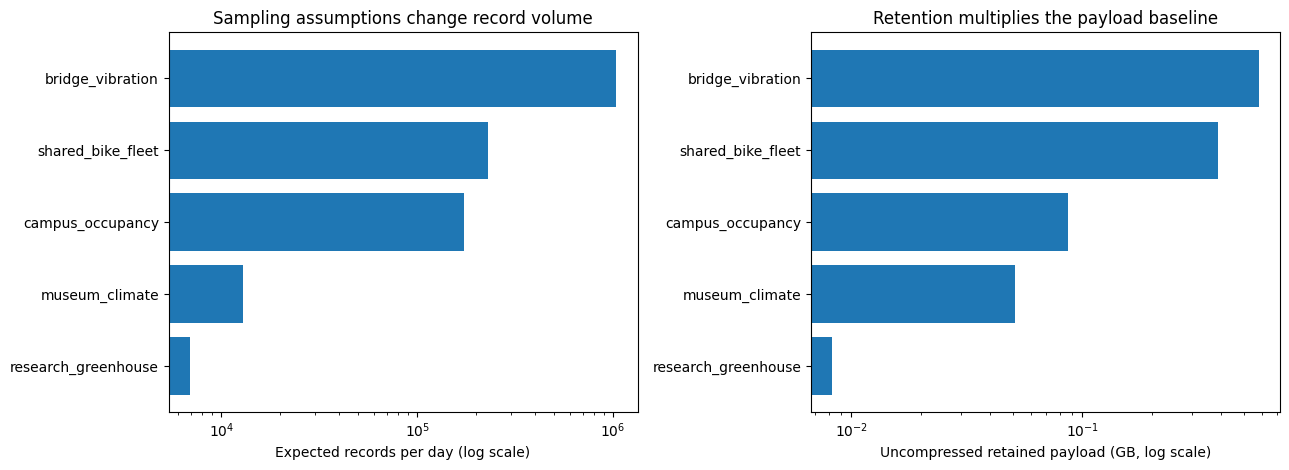

Saved outputs/scenario_summary.csv and fig_2_1_requirements.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
plot_df = summary.sort_values("expected_records_per_day")

axes[0].barh(plot_df["scenario"], plot_df["expected_records_per_day"])
axes[0].set_xscale("log")
axes[0].set_xlabel("Expected records per day (log scale)")
axes[0].set_title("Sampling assumptions change record volume")

axes[1].barh(plot_df["scenario"], plot_df["retained_uncompressed_payload_gb"])
axes[1].set_xscale("log")
axes[1].set_xlabel("Uncompressed retained payload (GB, log scale)")
axes[1].set_title("Retention multiplies the payload baseline")

fig.tight_layout()
fig.savefig("fig_2_1_requirements.png", dpi=180, bbox_inches="tight")
plt.show()

summary.to_csv(OUTPUTS / "scenario_summary.csv", index=False, float_format="%.6f")
print("Saved", OUTPUTS / "scenario_summary.csv", "and fig_2_1_requirements.png")


### Analysis

The same short function processes every row, but the record and payload volumes differ substantially. A small number of rapidly sampled monitoring points can generate more records than a much larger, slower fleet. The important point is not the synthetic ranking. It is that a technical assumption such as sampling interval propagates into downstream data volume.

The use-case columns keep that calculation attached to a physical purpose. The project asks not only **how much data?** but also **from what asset, observing what, over what communication context, for which decision, and with which outcome metric?**


---
## Exercise 2.3 — Repeat, Record Provenance, and Then Modify

The baseline pipeline is deterministic, so two runs with identical inputs should match exactly. That is a useful **repeatability check**, but it is not a claim that real IoT experiments are deterministic.

`run_pipeline` takes a **configuration file path**, not an in-memory number, and reloads that file on every call. This is what makes the second run genuinely config-driven: the saved `modified_config.json` file is the actual input to the second calculation, not just a record written alongside it. The full modified result is saved too, alongside the baseline, so both inputs and both outputs are on disk.

The comparison manifest fingerprints the artifacts that define each run: data, reusable source code, dependency policy, and **both** configuration files. SHA-256 is used only as a compact identifier. An unsigned hash is **not** proof against malicious substitution; an attacker who can replace a file may also be able to replace an unauthenticated expected hash.


In [6]:
def run_pipeline(config_path):
    """Run the full pipeline starting from a saved configuration *file*.

    Reloading ``config_path`` on every call (rather than accepting an
    in-memory ``interval_multiplier``) is what makes this function
    genuinely config-driven: the file on disk is the input, so a run
    against ``modified_config_file`` is actually driven by the modified
    configuration and not merely accompanied by it.
    """
    frame, run_cfg = load_inputs(scenario_file, config_path)
    result = estimate_footprint(frame, run_cfg["interval_multiplier"])
    return result, run_cfg

baseline_a, baseline_cfg_a = run_pipeline(config_file)
baseline_b, baseline_cfg_b = run_pipeline(config_file)
pd.testing.assert_frame_equal(baseline_a, baseline_b)

modified_cfg = dict(cfg)
modified_cfg["interval_multiplier"] = 5.0
modified_cfg["run_note"] = "Teaching sensitivity check: make the sampling interval five times longer."
modified_config_file = OUTPUTS / "modified_config.json"
modified_config_file.write_text(json.dumps(modified_cfg, indent=2), encoding="utf-8")

modified, modified_cfg_loaded = run_pipeline(modified_config_file)
modified_summary_file = OUTPUTS / "modified_scenario_summary.csv"
modified.to_csv(modified_summary_file, index=False, float_format="%.6f")

comparison_manifest = {
    "artifact_hashes": {
        "data": sha256_file(scenario_file),
        "source": sha256_file(source_file),
        "requirements": sha256_file(requirements_file),
        "baseline_config": sha256_file(config_file),
        "modified_config": sha256_file(modified_config_file),
        "baseline_scenario_summary": sha256_file(OUTPUTS / "scenario_summary.csv"),
        "modified_scenario_summary": sha256_file(modified_summary_file),
    },
    "python": platform.python_version(),
    "packages": manifest["packages"],
    "baseline_interval_multiplier": baseline_cfg_a["interval_multiplier"],
    "modified_interval_multiplier": modified_cfg_loaded["interval_multiplier"],
    "rows": len(baseline_a),
    "deterministic_repeat_equal": True,
}
(OUTPUTS / "comparison_manifest.json").write_text(
    json.dumps(comparison_manifest, indent=2), encoding="utf-8"
)

base = baseline_a.set_index("scenario").loc[cfg["selected_scenario"]]
mod = modified.set_index("scenario").loc[cfg["selected_scenario"]]
comparison = pd.DataFrame({
    "baseline": [base["expected_records_per_day"], base["retained_uncompressed_payload_gb"]],
    "modified": [mod["expected_records_per_day"], mod["retained_uncompressed_payload_gb"]],
}, index=["expected_records_per_day", "retained_uncompressed_payload_gb"])

print("Repeated baseline run: identical")
print("Baseline run used config:", config_file, "-> saved", OUTPUTS / "scenario_summary.csv")
print("Modified run used config:", modified_config_file, "-> saved", modified_summary_file)
print("Saved", OUTPUTS / "comparison_manifest.json")
comparison


Repeated baseline run: identical
Baseline run used config: config/project_config.json -> saved outputs/scenario_summary.csv
Modified run used config: outputs/modified_config.json -> saved outputs/modified_scenario_summary.csv
Saved outputs/comparison_manifest.json


,baseline,modified
expected_records_per_day,12960.000000,2592.000000
retained_uncompressed_payload_gb,0.051322,0.010264


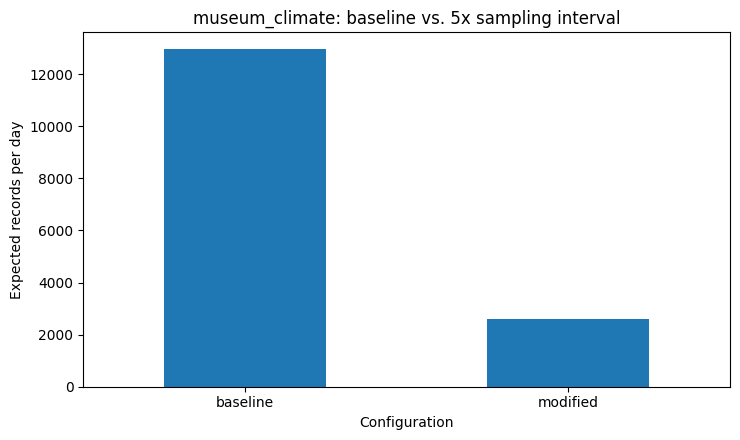

Baseline retained uncompressed payload: 0.051 GB
Modified retained uncompressed payload: 0.010 GB


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
comparison.loc[["expected_records_per_day"]].T.plot(kind="bar", ax=ax, legend=False)
ax.set_ylabel("Expected records per day")
ax.set_xlabel("Configuration")
ax.set_title(f"{cfg['selected_scenario']}: baseline vs. 5x sampling interval")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig("fig_2_2_reproducibility.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Baseline retained uncompressed payload: {base['retained_uncompressed_payload_gb']:.3f} GB")
print(f"Modified retained uncompressed payload: {mod['retained_uncompressed_payload_gb']:.3f} GB")


### Analysis — repeatability is not universal determinism

The baseline calculation contains no random process, so exact equality is expected. Real IoT work is often different: sensor noise, asynchronous events, network delay, operating-system scheduling, missing observations, clock drift, and physical variation can all make valid repeated trials differ.

For nondeterministic experiments, reproducible engineering means preserving enough evidence to explain and compare runs: raw timestamped observations where appropriate, dataset and firmware versions, source code, configuration, environment information, test conditions, and repeated-trial summaries. A fixed random seed can reproduce a **pseudorandom simulation stream**; it does not make a physical deployment deterministic.

### Challenge tasks

1. Change `selected_scenario` in the JSON file and rerun. **Hint:** no Python function should need to change.
2. Rename one required CSV column and observe the validation failure; then restore it.
3. Add a sixth scenario. **Hint:** copy one row and change both the use-case fields and synthetic numerical inputs.
4. Change `interval_multiplier` to `2.0`. Predict the direction of the record-count change before rerunning.
5. Add a `run_note` explaining why a configuration value changed.


---
## Practice Summary

You have worked with six distinct artifact roles:

- `requirements-ch02.txt` — dependency policy, installed *before* any third-party import;
- `data/iot_project_scenarios.csv` — synthetic use-case data, covering all five elements of the use-case anatomy;
- `config/project_config.json` — run configuration;
- `src/ch02_project.py` — reusable code;
- `outputs/` — generated manifests and both the baseline and modified results (`scenario_summary.csv`, `modified_scenario_summary.csv`);
- the chapter-root `.png` figures — publication assets copied out of `outputs/` for the typeset chapter, not themselves numerical run outputs.

The lesson is organizational rather than mathematically difficult. A project is easier to inspect and reproduce when another reader can identify its inputs, software environment, processing logic, checks, outputs, and intentional changes without reconstructing the author's intentions from memory.
